## Prerequisites

Runtime: Python 3, T4 GPU 

In [17]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [18]:
%pip install --no-deps -q bitsandbytes PyMuPDF
%pip install -q addict transformers==4.46.3 tokenizers==0.20.3

In [19]:
from transformers import AutoModel, AutoTokenizer, BitsAndBytesConfig

In [20]:
import torch

In [21]:
from pathlib import Path

WORKING_DIR = Path('/content/drive/MyDrive/aiOCR')
MODEL_NAME = 'deepseek-ai/DeepSeek-OCR'

qc = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float
)
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True)
model = AutoModel.from_pretrained(
    MODEL_NAME, trust_remote_code=True,
    use_safetensors=True, device_map="auto",
    quantization_config=qc, torch_dtype=torch.float
).eval()

You are using a model of type deepseek_vl_v2 to instantiate a model of type DeepseekOCR. This is not supported for all configurations of models and can yield errors.
Some weights of DeepseekOCRForCausalLM were not initialized from the model checkpoint at deepseek-ai/DeepSeek-OCR and are newly initialized: ['model.vision_model.embeddings.position_ids']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [22]:
IMAGE_FILE = WORKING_DIR / 'images/pineda1/pineda1_page_3.png'

## Inference

In [23]:
import tempfile

image_stem   = IMAGE_FILE.stem          
image_folder = IMAGE_FILE.parent.name   

# Local temp dir to avoid the model writing intermediate files to Drive
tmp_out = Path(tempfile.mkdtemp())

prompt = "<image>\n<|grounding|>Convert the document to Markdown and be as close to the original text as possible (including any typos and print errors). Use single asterisks for italics, double for bold, and triple asterisks for bold and italics. Include any additional Markdown formatting to represent the original text format.\n<|end_of_grounding|>\n"
with torch.no_grad():
    model.infer(
        tokenizer,
        prompt=prompt,
        image_file=str(IMAGE_FILE),
        output_path=tmp_out,
        base_size=1024,
        image_size=1024,
        crop_mode=False,
        save_results=True,
        test_compress=True,
        eval_mode=False
    )

/usr/local/lib/python3.12/dist-packages/transformers/generation/configuration_utils.py:590: UserWarning: `do_sample` is set to `False`. However, `temperature` is set to `0.0` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `temperature`.
  warnings.warn(
The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:None for open-end generation.


BASE:  torch.Size([1, 256, 1280])
NO PATCHES
0.0000000000000000000000000000000000000000000000000000000000000
<|ref|>text<|/ref|><|det|>[[240, 199, 830, 240]]<|/det|>
¿A DONDE VAMOS A PARAR? 

<|ref|>text<|/ref|><|det|>[[163, 363, 901, 431]]<|/det|>
A la familia i á cada uno de sus miembros, á los padres, á los hijos, á los jóvenes, á los ancianos. 

<|ref|>text<|/ref|><|det|>[[303, 473, 777, 503]]<|/det|>
¿Qué daño os ha hecho? 

<|ref|>text<|/ref|><|det|>[[520, 533, 556, 552]]<|/det|>
I. 

<|ref|>text<|/ref|><|det|>[[163, 575, 904, 860]]<|/det|>
A CERCABASE la hora fatal: Jas potestades de las tinieblas se habían desenfrenado; i hé aquí que todo un pueblo dominado de un espíritu de furor i de vértigo se apodera del Juzro. Eos propios discípulos de este, educados en su escuela, alimentados con su pan, colmados de caricias, sus discípulos que acaban de jurarle una fidelidad á toda prueba, le abandonan i le niegan: uno de ellos le ha vendido. Atado como un malhechor es conducido de tribu

image: 0it [00:00, ?it/s]
other: 100%|██████████| 5/5 [00:00<00:00, 68311.14it/s]


### Saving the output

In [24]:
import shutil

# OCR text → transcriptions/DeepSeek-OCR/<stem>.mmd
transcription_out = WORKING_DIR / 'transcriptions/DeepSeek-OCR'
transcription_out.mkdir(parents=True, exist_ok=True)
shutil.copy(tmp_out / 'result.mmd', transcription_out / f'{image_stem}.mmd')
print(f"Saved: transcriptions/DeepSeek-OCR/{image_stem}.mmd")

# Segmented image → segmented/DeepSeek-OCR/<folder>/<stem>.jpg  (mirrors images/ layout)
segmented_out = WORKING_DIR / 'segmented/DeepSeek-OCR' / image_folder
segmented_out.mkdir(parents=True, exist_ok=True)
shutil.copy(tmp_out / 'result_with_boxes.jpg', segmented_out / f'{image_stem}.jpg')
print(f"Saved: segmented/DeepSeek-OCR/{image_folder}/{image_stem}.jpg")

Saved: transcriptions/DeepSeek-OCR/pineda1_page_3.mmd
Saved: segmented/DeepSeek-OCR/pineda1/pineda1_page_3.jpg


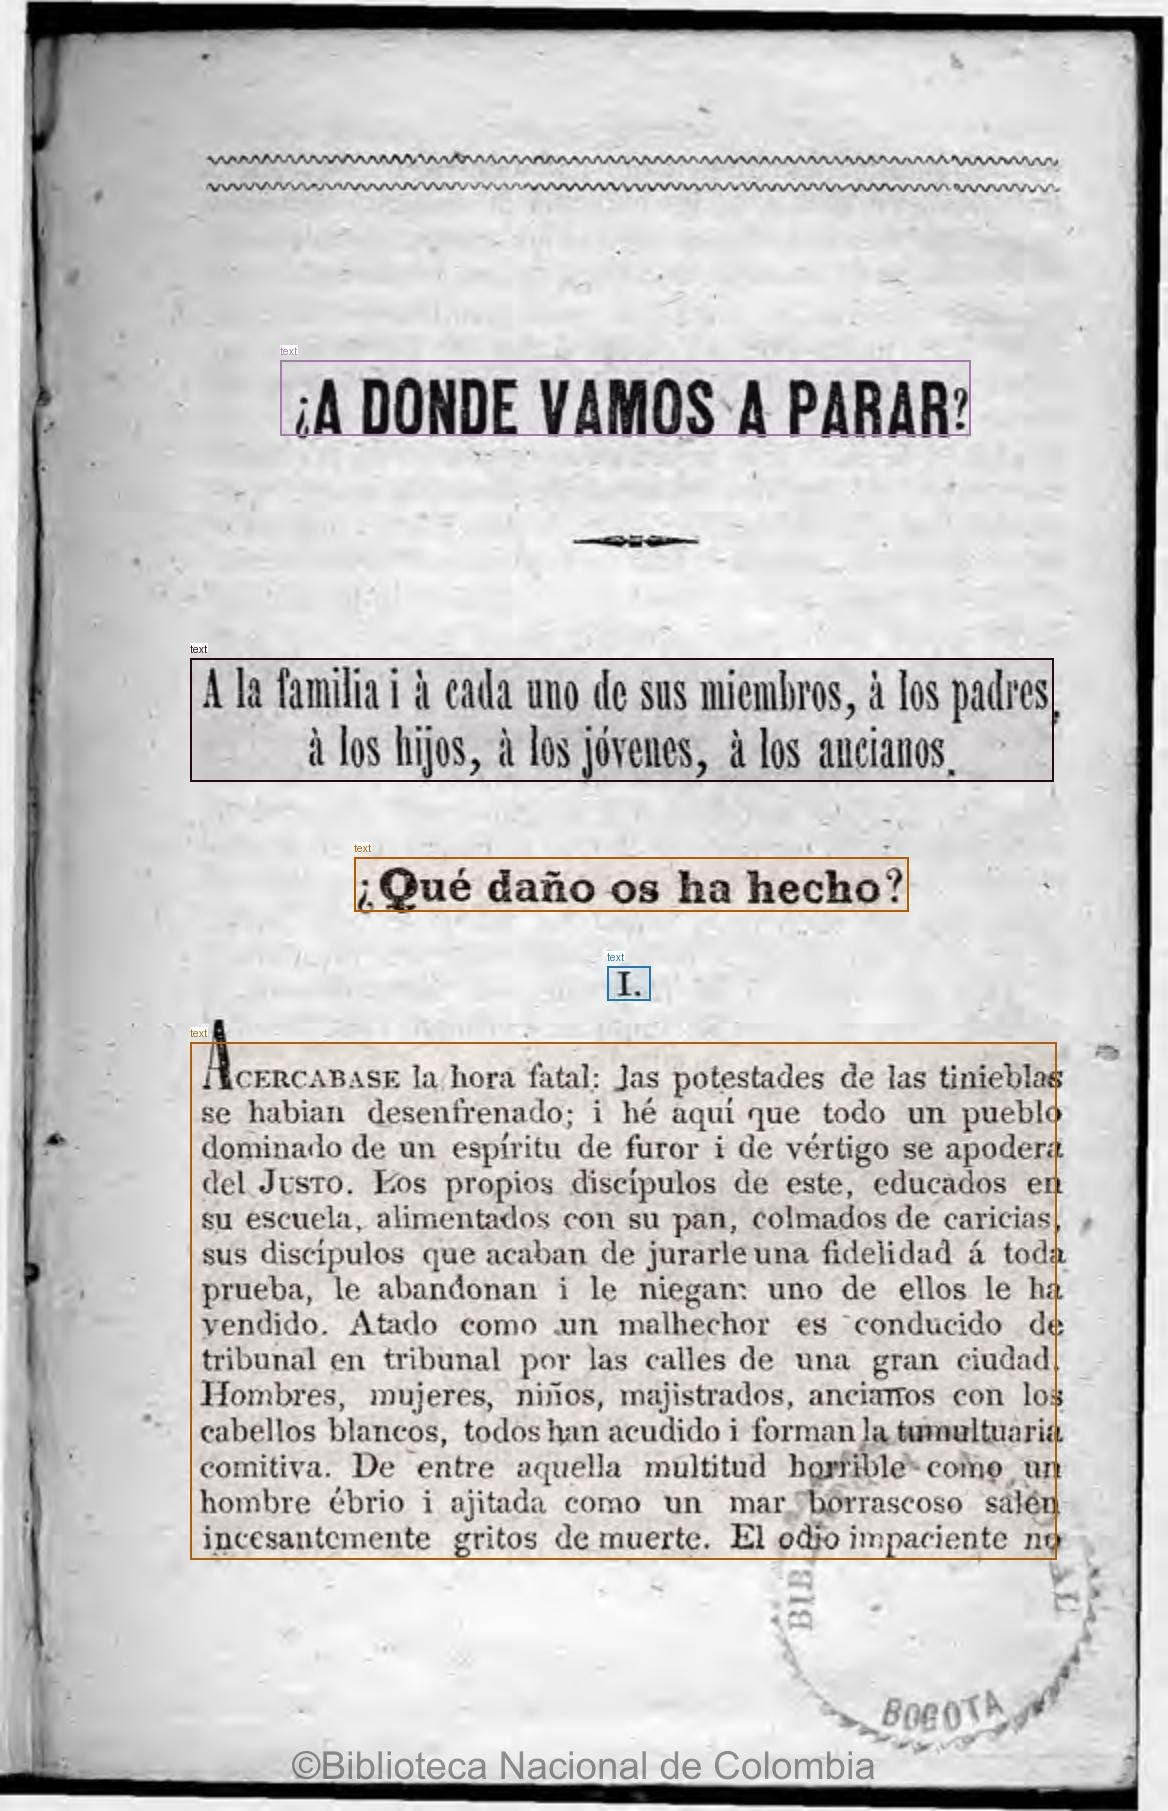

In [25]:
from IPython.display import Image as IPImage
IPImage(filename=str(segmented_out / f'{image_stem}.jpg'), width=600)